In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [3]:
train.shape
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                80000 non-null  object 
 1   site_id                   80000 non-null  object 
 2   triage_nurse_id           80000 non-null  object 
 3   arrival_mode              80000 non-null  object 
 4   arrival_hour              80000 non-null  int64  
 5   arrival_day               80000 non-null  object 
 6   arrival_month             80000 non-null  int64  
 7   arrival_season            80000 non-null  object 
 8   shift                     80000 non-null  object 
 9   age                       80000 non-null  int64  
 10  age_group                 80000 non-null  object 
 11  sex                       80000 non-null  object 
 12  language                  80000 non-null  object 
 13  insurance_type            80000 non-null  object 
 14  transp

In [4]:
train.isnull().sum()

patient_id                     0
site_id                        0
triage_nurse_id                0
arrival_mode                   0
arrival_hour                   0
arrival_day                    0
arrival_month                  0
arrival_season                 0
shift                          0
age                            0
age_group                      0
sex                            0
language                       0
insurance_type                 0
transport_origin               0
pain_location                  0
mental_status_triage           0
chief_complaint_system         0
num_prior_ed_visits_12m        0
num_prior_admissions_12m       0
num_active_medications         0
num_comorbidities              0
systolic_bp                 4146
diastolic_bp                4146
mean_arterial_pressure      4146
pulse_pressure              4146
heart_rate                     0
respiratory_rate            3067
temperature_c                574
spo2                           0
gcs_total 

<Axes: xlabel='triage_acuity', ylabel='count'>

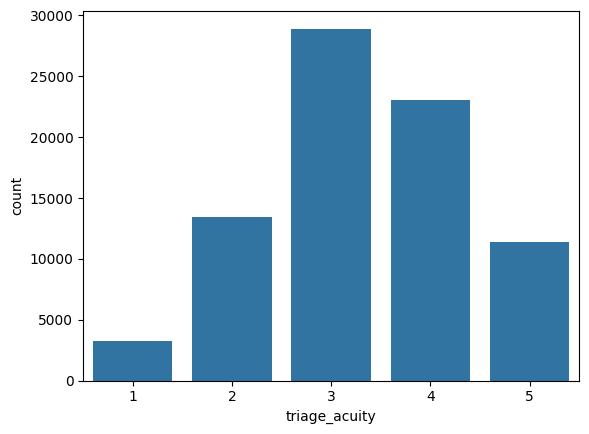

In [5]:
sns.countplot(x="triage_acuity", data=train)

In [6]:
train.isnull().sum().sort_values(ascending=False)

systolic_bp                 4146
diastolic_bp                4146
mean_arterial_pressure      4146
shock_index                 4146
pulse_pressure              4146
respiratory_rate            3067
temperature_c                574
patient_id                     0
spo2                           0
heart_rate                     0
gcs_total                      0
site_id                        0
pain_score                     0
weight_kg                      0
height_cm                      0
bmi                            0
news2_score                    0
disposition                    0
ed_los_hours                   0
num_comorbidities              0
num_active_medications         0
num_prior_admissions_12m       0
age                            0
triage_nurse_id                0
arrival_mode                   0
arrival_hour                   0
arrival_day                    0
arrival_month                  0
arrival_season                 0
shift                          0
age_group 

<Axes: xlabel='pain_score', ylabel='Count'>

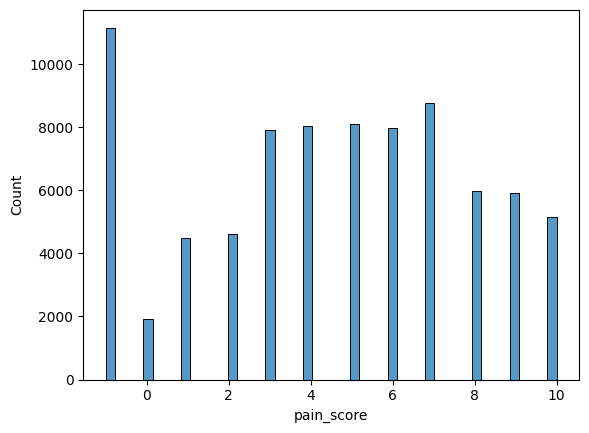

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train["pain_score"])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# Assuming 'train' is a pandas DataFrame
# Identify categorical columns that need encoding
categorical_columns = train.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply LabelEncoder or OneHotEncoder to the required columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_features = pd.DataFrame(encoder.fit_transform(train[categorical_columns]))
encoded_features.columns = encoder.get_feature_names_out(categorical_columns)

# Drop original categorical columns and concatenate encoded features
train = train.drop(categorical_columns, axis=1)
train = pd.concat([train, encoded_features], axis=1)

# Split features and target
X = train.drop("triage_acuity", axis=1)
y = train["triage_acuity"]

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and calculate accuracy
preds = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, preds))